# OCR-based Image Classification

## Imports

In [1]:
import sys
sys.path.append(r"C:\Users\ibf\Desktop\TFM\Nou_projecte")

from TFM.Utils.ocr_utils import *

# Install required Python packages if missing (Tesseract is system-level)
ensure_package('pytesseract')
ensure_package('Pillow', 'PIL')
ensure_package('scikit-learn', 'sklearn')
ensure_package('joblib')
ensure_package('pandas')
ensure_package('tqdm')
ensure_package('numpy')
ensure_package('matplotlib')

print(sys.executable)
!{sys.executable} -m pip show opencv-python

OK: pytesseract available
OK: Pillow available
OK: scikit-learn available
OK: joblib available
OK: pandas available
OK: tqdm available
OK: numpy available
OK: matplotlib available
c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Scripts\python.exe
Name: opencv-python
Version: 4.13.0.92
Summary: Wrapper package for OpenCV python bindings.
Home-page: https://github.com/opencv/opencv-python
Author: 
Author-email: 
License: Apache 2.0
Location: c:\Users\ibf\Desktop\TFM\Nou_projecte\.venv\Lib\site-packages
Requires: numpy
Required-by: 


In [2]:
ROOT = Path('..').resolve().parent
DATA_DIR = ROOT / 'Data'
MODELS_DIR = ROOT / 'TFM' / 'Models'
MODELS_DIR.mkdir(exist_ok=True)
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.webp')
CONFIDENCE_THRESHOLD = 0.90
SEED = 42


# Create output folder if needed
OUTPUT_DIR = Path("ocr_cache")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

configure_tesseract()

pytesseract version: 5.5.0.20241111


## DATA Splitting

In [3]:
# Load all data
class_names, all_samples = collect_samples(DATA_DIR, IMAGE_EXTENSIONS)

# Map labels to indices (needed for stratification)
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

all_paths = [path for path, _ in all_samples]
all_labels = np.array([class_to_idx[label] for _, label in all_samples], dtype=np.int64)

# Stratified split
train_paths, val_paths, train_targets, val_targets = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    random_state=SEED,
    stratify=all_labels,
)

# Convert back to label names
idx_to_class = {v: k for k, v in class_to_idx.items()}

train_samples = [(path, idx_to_class[label]) for path, label in zip(train_paths, train_targets)]
val_samples = [(path, idx_to_class[label]) for path, label in zip(val_paths, val_targets)]

num_classes = len(class_names)

# Count occurrences
all_counts = Counter(all_labels.tolist())
train_counts = Counter(train_targets.tolist())
val_counts = Counter(val_targets.tolist())

all_image_counts = {class_names[idx]: all_counts.get(idx, 0) for idx in range(num_classes)}
train_image_counts = {class_names[idx]: train_counts.get(idx, 0) for idx in range(num_classes)}
val_image_counts = {class_names[idx]: val_counts.get(idx, 0) for idx in range(num_classes)}

print(f"Top-level class labels: {class_names}")
print(f"Number of classes: {num_classes}")

print("\nData image counts by class:")
for class_name in class_names:
    print(f"{class_name}: {all_image_counts[class_name]} images")

print("\nTraining image counts by class (80% split):")
for class_name in class_names:
    print(f"{class_name}: {train_image_counts[class_name]} images")

print("\nValidation image counts by class (20% split):")
for class_name in class_names:
    print(f"{class_name}: {val_image_counts[class_name]} images")

total_data_images = len(all_paths)
total_train_images = len(train_paths)
total_val_images = len(val_paths)

print(f"\nTotal images in Data: {total_data_images}")
print(f"Total training images: {total_train_images}")
print(f"Total validation images: {total_val_images}")

summary_df = pd.DataFrame({
    'Category': class_names,
    'Data Image Count': [all_image_counts[name] for name in class_names],
    'Train Image Count': [train_image_counts[name] for name in class_names],
    'Val Image Count': [val_image_counts[name] for name in class_names],
    'Train Percentage': [f"{100 * train_image_counts[name] / max(total_train_images, 1):.1f}%" for name in class_names],
    'Val Percentage': [f"{100 * val_image_counts[name] / max(total_val_images, 1):.1f}%" for name in class_names],
})

print("\nData Summary:")
print(summary_df)

Top-level class labels: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of classes: 8

Data image counts by class:
Banner aplicación: 199 images
Cierre aplicación: 523 images
Error aplicativo: 608 images
Error funcional: 592 images
Error terminal: 1125 images
Indeterminado: 50 images
Revisión circuito: 3351 images
Timeout: 376 images

Training image counts by class (80% split):
Banner aplicación: 159 images
Cierre aplicación: 418 images
Error aplicativo: 486 images
Error funcional: 474 images
Error terminal: 900 images
Indeterminado: 40 images
Revisión circuito: 2681 images
Timeout: 301 images

Validation image counts by class (20% split):
Banner aplicación: 40 images
Cierre aplicación: 105 images
Error aplicativo: 122 images
Error funcional: 118 images
Error terminal: 225 images
Indeterminado: 10 images
Revisión circuito: 670 images
Timeout: 75 images

Total images in Data: 6824

## OCR and Extraction executing

In [ ]:
train_df = build_ocr_dataframe_from_samples(train_samples, class_names, 'train')
val_df = build_ocr_dataframe_from_samples(val_samples, class_names, 'val')
if 'Uncertain' not in class_names:
    class_names.append('Uncertain')

print('Class names:', class_names)

OCR train: 100%|██████████| 5459/5459 [3:06:52<00:00,  2.05s/it]     


train samples: 5459
train empty OCR texts: 771


OCR val:  80%|████████  | 1096/1365 [28:02<09:03,  2.02s/it] 

Save

In [ ]:
train_path = OUTPUT_DIR / "train_ocr.parquet"
val_path = OUTPUT_DIR / "val_ocr.parquet"

train_df.to_parquet(train_path, index=False)
val_df.to_parquet(val_path, index=False)

print(f"Saved to {train_path} and {val_path}")

Saved to ocr_cache\train_ocr.parquet and ocr_cache\val_ocr.parquet


Load

In [ ]:
train_df = pd.read_parquet("ocr_cache/train_ocr.parquet")
val_df = pd.read_parquet("ocr_cache/val_ocr.parquet")

# Rebuild class names if needed
class_names = sorted(set(train_df['label']) | set(val_df['label']))
if 'Uncertain' not in class_names:
    class_names.append('Uncertain')

## Classifier

### Classificator SVC

In [ ]:
# sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
clf = SVC(probability=True)

def filter_empty_samples(df):
    return df[df['text'].str.strip() != ""].copy()

train_df_clean = filter_empty_samples(train_df)
val_df_clean = filter_empty_samples(val_df)

embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

def compute_embeddings(texts, model, batch_size=32):
    embeddings = model.encode(
        texts.tolist(),
        batch_size=batch_size,
        show_progress_bar=True
    )
    return np.array(embeddings)

X_train = compute_embeddings(train_df_clean['text'], embedding_model)
X_val = compute_embeddings(val_df_clean['text'], embedding_model)

y_train = train_df_clean['label']
y_val = val_df_clean['label']

clf.fit(X_train, y_train)

Batches: 100%|██████████| 37/37 [00:16<00:00,  2.31it/s]


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### XGBoost

In [ ]:
"""
def filter_empty_samples(df):
    return df[df['text'].str.strip() != ""].copy()

# ✅ Filter first
train_df_clean = filter_empty_samples(train_df)
val_df_clean = filter_empty_samples(val_df)

# ✅ Extract labels AFTER filtering
y_train = train_df_clean['label']
y_val = val_df_clean['label']

# ✅ Encode AFTER filtering
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# ✅ Embeddings
embedding_model = SentenceTransformer(
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

def compute_embeddings(texts, model, batch_size=32):
    return np.array(
        model.encode(texts.tolist(), batch_size=batch_size, show_progress_bar=True)
    )
X_train = compute_embeddings(train_df_clean['text'], embedding_model)
X_val = compute_embeddings(val_df_clean['text'], embedding_model)

# ✅ Model
from xgboost import XGBClassifier

clf = XGBClassifier(
    objective='multi:softprob',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
)

# ✅ Train
clf.fit(X_train, y_train_encoded)

# ✅ Predict + decode
y_pred_encoded = clf.predict(X_val)
y_pred = le.inverse_transform(y_pred_encoded)
"""

'\ndef filter_empty_samples(df):\n    return df[df[\'text\'].str.strip() != ""].copy()\n\n# ✅ Filter first\ntrain_df_clean = filter_empty_samples(train_df)\nval_df_clean = filter_empty_samples(val_df)\n\n# ✅ Extract labels AFTER filtering\ny_train = train_df_clean[\'label\']\ny_val = val_df_clean[\'label\']\n\n# ✅ Encode AFTER filtering\nfrom sklearn.preprocessing import LabelEncoder\nle = LabelEncoder()\n\ny_train_encoded = le.fit_transform(y_train)\ny_val_encoded = le.transform(y_val)\n\n# ✅ Embeddings\nembedding_model = SentenceTransformer(\n    \'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2\'\n)\n\ndef compute_embeddings(texts, model, batch_size=32):\n    return np.array(\n        model.encode(texts.tolist(), batch_size=batch_size, show_progress_bar=True)\n    )\nX_train = compute_embeddings(train_df_clean[\'text\'], embedding_model)\nX_val = compute_embeddings(val_df_clean[\'text\'], embedding_model)\n\n# ✅ Model\nfrom xgboost import XGBClassifier\n\nclf = XGBClassi

### Evaluate

In [ ]:

OCR_THR = 0.90

# For SVC
y_pred = predict_with_rules(val_df, embedding_model, clf, threshold=OCR_THR)
# For XGB
# y_pred = predict_with_rules_xgb(val_df, embedding_model, clf, le, threshold=OCR_THR)
extended_classes = sorted(list(set(class_names) | {"Empty"}))
print(classification_report(val_df['label'], y_pred, labels=extended_classes))

print(f"Evaluating on VAL with confidence threshold: {OCR_THR}")

scores = evaluate_predictions(val_df['label'], y_pred)
print("Scores:")
print(scores)

y_pred_no_empty = predict_with_rules(val_df_clean, embedding_model, clf, threshold=OCR_THR)

scores_no_empty = evaluate_predictions(val_df_clean['label'], y_pred_no_empty)

print("Scores (no empty):")
print(scores_no_empty)

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

Batches: 100%|██████████| 43/43 [00:17<00:00,  2.49it/s]


                   precision    recall  f1-score   support

Banner aplicación       1.00      0.93      0.96        40
Cierre aplicación       1.00      0.40      0.57       105
            Empty       0.00      0.00      0.00         0
 Error aplicativo       0.99      0.97      0.98       122
  Error funcional       1.00      0.99      1.00       118
   Error terminal       1.00      0.70      0.83       225
    Indeterminado       0.00      0.00      0.00        10
Revisión circuito       1.00      0.99      0.99       670
          Timeout       1.00      0.21      0.35        75
        Uncertain       0.00      0.00      0.00         0

         accuracy                           0.84      1365
        macro avg       0.70      0.52      0.57      1365
     weighted avg       0.99      0.84      0.89      1365

Evaluating on VAL with confidence threshold: 0.9
Scores:
{'accuracy': 0.8432234432234432, 'balanced_accuracy': 0.6486057916055548, 'macro_f1': 0.6307437690234954, 'weighte

Batches: 100%|██████████| 37/37 [00:16<00:00,  2.18it/s]


Scores (no empty):
{'accuracy': 0.9820819112627986, 'balanced_accuracy': 0.8373118163260485, 'macro_f1': 0.8546512493802949, 'weighted_f1': 0.9887364490661853, 'uncertain_rate': np.float64(0.014505119453924915)}


In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np

# -----------------------------
# Save directory
# -----------------------------
MODEL_DIR = Path("../Models/ocr_text_classifier_v3")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1. Save classifier
# -----------------------------
joblib.dump(clf, MODEL_DIR / "ocr_clf.joblib")

# -----------------------------
# 2. Save label classes
# -----------------------------
joblib.dump(clf.classes_, MODEL_DIR / "classes.joblib")

# -----------------------------
# 3. Save embedding model
# -----------------------------
embedding_model.save(MODEL_DIR / "embedding_model")

# -----------------------------
# 4. Save config (VERY IMPORTANT for production)
# -----------------------------
config = {
    "embedding_model_name": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "threshold": OCR_THR if "OCR_THR" in globals() else None,
    "model_type": "SVC",
    "probability": True,
}

with open(MODEL_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

# -----------------------------
# 5. (Optional but recommended) Save training metadata
# -----------------------------
metadata = {
    "n_train_samples": len(train_df_clean),
    "n_val_samples": len(val_df_clean),
    "embedding_dim": X_train.shape[1],
    "num_classes": len(clf.classes_),
}

with open(MODEL_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Model saved to:", MODEL_DIR.resolve())

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.63s/it]

Model saved to: C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Model_Notebooks\models\ocr_text_classifier_v3


: 

### Save predictions

In [ ]:
# ---- Predict ----
y_pred = predict_with_rules(val_df, embedding_model, clf, threshold=OCR_THR)

# ---- Build evaluation dataframe (VERY IMPORTANT) ----
texts = val_df['text'].tolist()
embeddings = embedding_model.encode(texts, show_progress_bar=True)

probas = clf.predict_proba(embeddings)
classes = clf.classes_

max_probs = probas.max(axis=1)
predicted_classes = [classes[np.argmax(p)] for p in probas]

eval_df = val_df.copy()
eval_df["prediction"] = y_pred
eval_df["predicted_class_raw"] = predicted_classes  # before threshold/rules
eval_df["max_probability"] = max_probs
eval_df["threshold"] = OCR_THR

# ---- Scores ----
scores = evaluate_predictions(val_df['label'], y_pred)

# ---- Save artifacts ----
# (NOTE: no vectorizer anymore — embeddings model is external)
dump(clf, MODELS_DIR / 'ocr_text_classifier_3.joblib')

# Optional: save class list for reproducibility
dump(classes, MODELS_DIR / 'ocr_classes_3.joblib')

# Save datasets
train_df.to_csv(MODELS_DIR / 'ocr_samples_train_3.csv', index=False)
val_df.to_csv(MODELS_DIR / 'ocr_samples_val_3.csv', index=False)

# Save evaluation outputs
eval_df.to_csv(
    MODELS_DIR / f'ocr_validation_predictions_threshold_{str(OCR_THR).replace(".", "p")}_v3.csv',
    index=False
)

# Save scores
with open(MODELS_DIR / 'ocr_validation_scores.json', 'w', encoding='utf-8') as f:
    json.dump(scores, f, indent=2, ensure_ascii=False)

print('Saved model artifacts to', MODELS_DIR.resolve())

Batches: 100%|██████████| 43/43 [00:16<00:00,  2.68it/s]


Saved model artifacts to C:\Users\ibf\Desktop\TFM\Nou_projecte\TFM\Models


### Confusion matrix

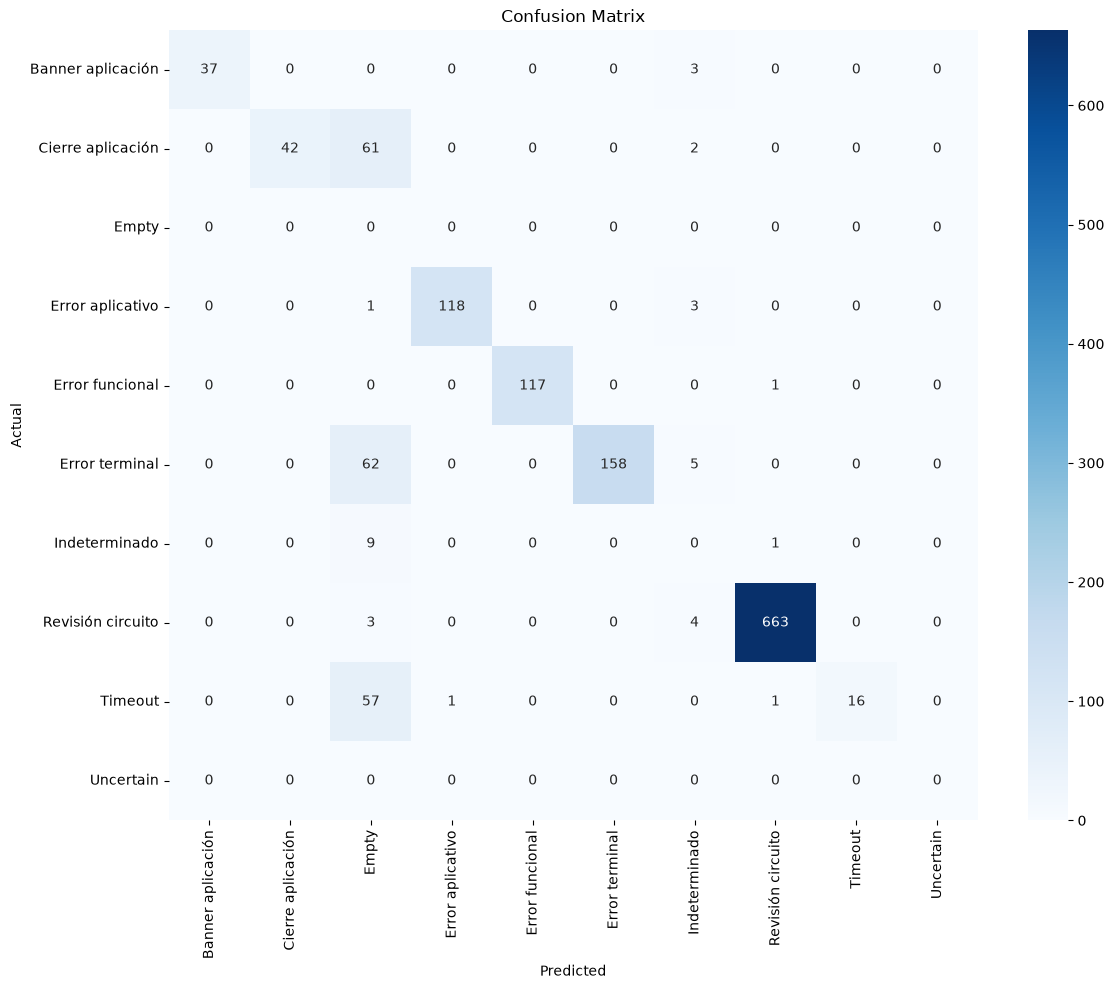

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(val_df['label'], y_pred, labels=extended_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=extended_classes,
    yticklabels=extended_classes
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()

plt.show()

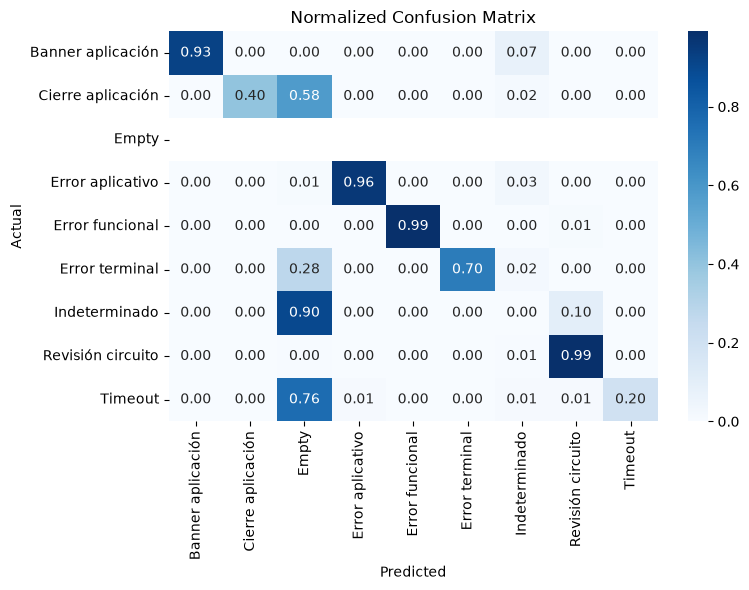

In [ ]:
import numpy as np

cm = confusion_matrix(val_df['label'], y_pred, labels=extended_classes)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=extended_classes,
    yticklabels=extended_classes
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Normalized Confusion Matrix')
plt.tight_layout()

plt.show()

### Logistic Regression

In [ ]:
"""# Train the OCR classifier on all Data images
if train_df['text'].fillna('').str.strip().eq('').all():
    raise RuntimeError('OCR returned empty text for every training image. Tesseract is required for this notebook.')

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['text'].fillna(''))
y_train = train_df['label']

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)
print('Training complete.')
print('Train samples:', len(train_df))
print('Validation samples:', len(val_df))"""

Training complete.
Train samples: 5459
Validation samples: 1365


Evaluating on VAL with confidence threshold: 0.8
Scores:
{
  "accuracy": 0.6813186813186813,
  "balanced_accuracy": 0.6896487594625216,
  "macro_f1": 0.6602285864643774,
  "weighted_f1": 0.7860765612471432,
  "uncertain_rate": 0.326007326007326
}

Classification report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      0.82      0.90        40
Cierre aplicación       1.00      0.35      0.52       105
 Error aplicativo       1.00      0.86      0.93       122
  Error funcional       1.00      0.97      0.99       118
   Error terminal       1.00      0.60      0.75       225
    Indeterminado       0.02      1.00      0.04        10
Revisión circuito       1.00      0.72      0.84       670
          Timeout       1.00      0.19      0.31        75

         accuracy                           0.68      1365
        macro avg       0.88      0.69      0.66      1365
     weighted avg       0.99      0.68      0.79      1365



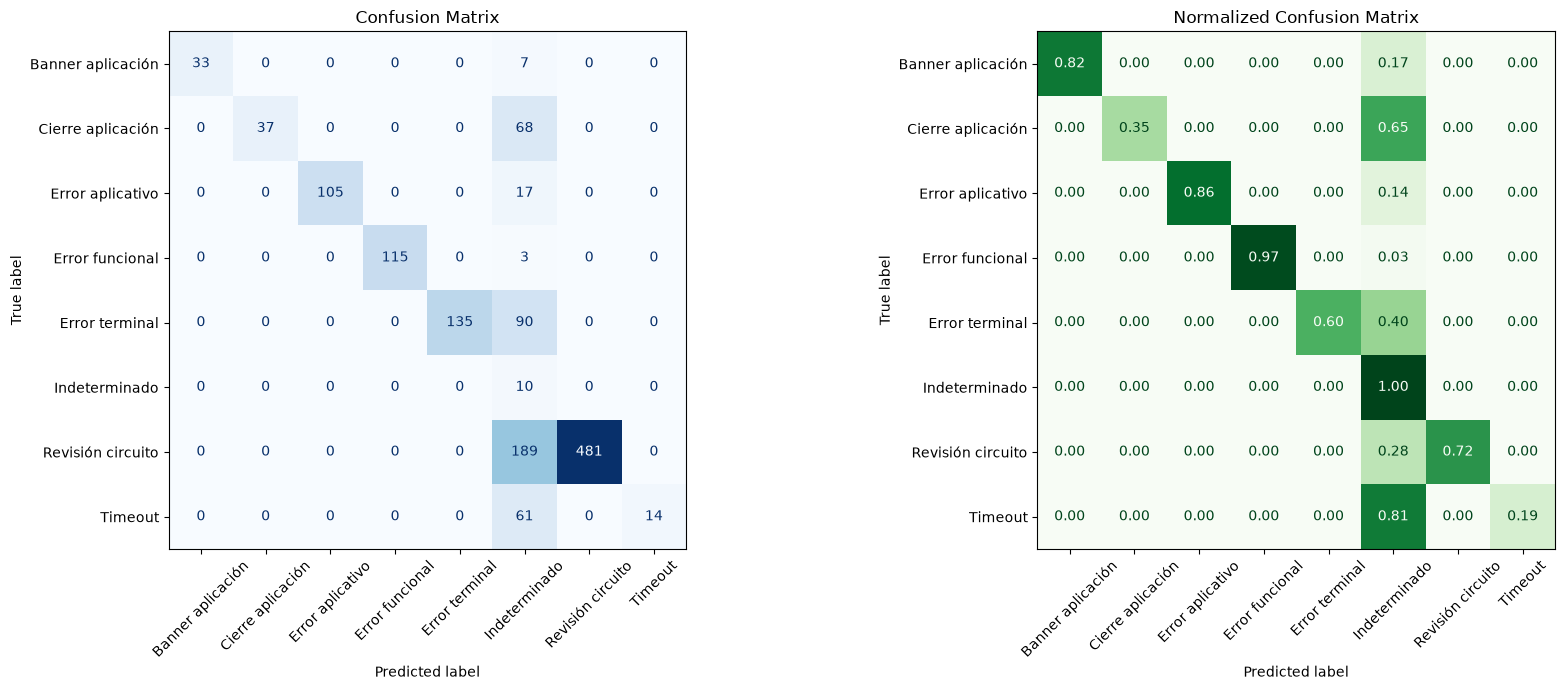

Validation rows: 1365


In [ ]:
"""
# Evaluate on VAL with the {CONFIDENCE_THRESHOLD} confidence rule
print('Evaluating on VAL with confidence threshold:', CONFIDENCE_THRESHOLD)
X_val = vectorizer.transform(val_df['text'].fillna(''))
val_probabilities = clf.predict_proba(X_val)
raw_indices = val_probabilities.argmax(axis=1)
raw_labels = clf.classes_[raw_indices]
confidence = val_probabilities.max(axis=1)
final_labels = np.where(confidence >= CONFIDENCE_THRESHOLD, raw_labels, 'Indeterminado')

eval_df = val_df.copy().reset_index(drop=True)
eval_df['raw_prediction'] = raw_labels
eval_df['confidence'] = confidence
eval_df['prediction'] = final_labels
eval_df['is_indeterminate'] = eval_df['prediction'].eq('Indeterminado')

scores = {
    'accuracy': float(accuracy_score(eval_df['label'], eval_df['prediction'])),
    'balanced_accuracy': float(balanced_accuracy_score(eval_df['label'], eval_df['prediction'])),
    'macro_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='macro', zero_division=0)),
    'weighted_f1': float(f1_score(eval_df['label'], eval_df['prediction'], average='weighted', zero_division=0)),
    'uncertain_rate': float(eval_df['is_indeterminate'].mean()),
}

print('Scores:')
print(json.dumps(scores, indent=2))
print('\nClassification report:')
print(classification_report(eval_df['label'], eval_df['prediction'], labels=class_names, zero_division=0))

cm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names)
cm_norm = confusion_matrix(eval_df['label'], eval_df['prediction'], labels=class_names, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=45)
axes[0].set_title('Confusion Matrix')
ConfusionMatrixDisplay(cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45, values_format='.2f')
axes[1].set_title('Normalized Confusion Matrix')
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ocr_confusion_matrix_2.png', dpi=200, bbox_inches='tight')
plt.show()

print('Validation rows:', len(eval_df))

"""

In [ ]:
"""# Inference helper with the same confidence rule
def predict_image_class_from_ocr(image_path, confidence_threshold=CONFIDENCE_THRESHOLD, vectorizer_path=MODELS_DIR / 'ocr_vectorizer_2.joblib', clf_path=MODELS_DIR / 'ocr_text_classifier_2.joblib'):
    vec = load(vectorizer_path)
    model = load(clf_path)
    text = extract_text_from_image(image_path)
    if not text:
        return {'predicted': 'Indeterminado', 'raw_prediction': 'Indeterminado', 'confidence': 0.0, 'text': ''}
    features = vec.transform([text])
    probabilities = model.predict_proba(features)[0]
    index = int(probabilities.argmax())
    raw_label = model.classes_[index]
    confidence = float(probabilities[index])
    predicted = raw_label if confidence >= confidence_threshold else 'Indeterminado'
    return {'predicted': predicted, 'raw_prediction': raw_label, 'confidence': confidence, 'text': text}

example_path = val_df.iloc[0]['path'] if len(val_df) else train_df.iloc[0]['path']
print('Example path:', example_path)
print(predict_image_class_from_ocr(example_path))"""

Example path: C:\Users\ibf\Desktop\TFM\Nou_projecte\Data\Banner aplicación\Actualizar app\20260506060020_100171.png
{'predicted': 'Banner aplicación', 'raw_prediction': 'Banner aplicación', 'confidence': 0.9806543519359983, 'text': 'Actualiza la app\n\nEsta versión de la app dejará de estar\ndisponible.\n\nPor favor, actualiza la app para seguir\ndisfrutando de CaixaBankNow y todas las\nnuevas funcionalidades y mejoras de\nseguridad y normativas.\n\nGracias y disculpa las molestias.\n\nActualizar más tarde'}
